# Natural Language Processing: E-Commerce Products Classification

## Problem Statement

### Context

Product categorization also referred to as product classification, is a field of study within natural language processing (NLP). It is also one of the biggest challenges for e-commerce companies. With the advancement of AI technology, researchers have been applying machine learning to product categorization problems.

Product categorization is the placement and organization of products into their respective categories. In that sense, it sounds simple: choose the correct department for a product. However, this process is complicated by the sheer volume of products on many e-commerce platforms. Furthermore, many products could belong to multiple categories.

There are many reasons why product categorization is important for e-commerce and marketing. Through the accurate classification of your products, you can increase conversion rates, strengthen your search engine, and improve your site’s Google ranking.

### Objective

The aim of the project is to build a classification model that can accurately classify product descriptions into the predefined categories of "Household," "Clothing & Accessories," "Electronics," and "Books."
Perform all the steps mentioned below. Provide comments and clear outputs in each cell.

### Data Dictionary

* Label - Class name
* Text - Description from the e-commerce website  

## Importing necessary libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Importing the Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Deep Learning
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.utils import to_categorical

# WordCloud
from wordcloud import WordCloud

#To handle contractions "I'm -> I am"
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [5]:
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Loading the dataset

In [6]:
# Mount Google drive to access the dataset only if you are using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
ls "/content/drive/MyDrive/16th Week Intro to Neural NW/18th NLP/Project1"

ecommerceDataset.csv       NLP_Learner_Notebook.ipynb              Tweets.csv
NLP_Learner_Notebook.html  Question_Notebook_NLP_E_Commerce.ipynb


In [8]:
# read the data
df = pd.read_csv("/content/drive/MyDrive/16th Week Intro to Neural NW/18th NLP/Project1/ecommerceDataset.csv")

## Data Overview

The initial steps to get an overview of any dataset is to:
- Observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- Get information about the number of rows and columns in the dataset
- Find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.

In [9]:
# Check shape
print("Shape of dataset Number of rows/columns:", df.shape)

# First few rows
df.head()

Shape of dataset Number of rows/columns: (50424, 2)


,Label,Text
0,Household,Styleys Wrought Iron Coat Rack Hanger Creative...
1,Household,Cuisinart CCO-50BKN Deluxe Electric Can Opener...
2,Household,Anchor Penta 6 Amp 1 -Way Switch (White) - Pac...
3,Clothing & Accessories,"Proline Men's Track Jacket Proline Woven, 100%..."
4,Household,Chef's Garage 2 Slot Edge Grip Kitchen Knife S...


In [10]:
df.tail()

,Label,Text
50419,Books,"The Circadian Code: Lose weight, supercharge y..."
50420,Clothing & Accessories,LACE AND ME Grip Wire No Rolling Down Tummy Tu...
50421,Clothing & Accessories,aarbee Women's Blended Cardigan aarbee women's...
50422,Books,Fundamentals of Agriculture Vol.-1&2 Fundament...
50423,Household,3d Creations Aluminium Espresso Stove Percolat...


In [11]:
df.isnull().sum()

,0
Label,0
Text,1


Missing value exists thus removing the missing row

In [12]:
#Missing value exist thus dropping the same
df.dropna(inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50423 entries, 0 to 50423
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Label   50423 non-null  object
 1   Text    50423 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [14]:
df.columns

Index(['Label', 'Text'], dtype='object')

In [15]:
df.isnull().sum()

,0
Label,0
Text,0


In [16]:
# checking for duplicate values
df.duplicated().sum()

np.int64(22622)

There are almost half of the rows are duplicate, thus removing duplicate rows

In [17]:
# dropping the duplicates
df = df.drop_duplicates(keep = 'first')

# checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27801 entries, 0 to 50421
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Label   27801 non-null  object
 1   Text    27801 non-null  object
dtypes: object(2)
memory usage: 651.6+ KB


In [19]:
# resetting the index of the dataframe
df = df.reset_index(drop = True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27801 entries, 0 to 27800
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Label   27801 non-null  object
 1   Text    27801 non-null  object
dtypes: object(2)
memory usage: 434.5+ KB


In [21]:
df.isna().sum()

,0
Label,0
Text,0


- 22622 number of duplicate data observed thus removed them
- 1 missing value observed which is removed.
- The considered dataset has two fields Label and Text

## Exploratory Data Analysis

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

- What is the percentage of text for each label
- How does a wordcloud appear for  Household category?
- How does a wordcloud appear for  Clothing & Accessories category?
- How does a wordcloud appear for  Electronics category?
- How does a wordcloud appear for  Books category?
- What are insights observed from EDA?

In [22]:
# Plot the distribution of the class label
def bar_plot(data, feature):
    # Creating the countplot
    plot = sns.countplot(x = feature, data = data)

    # Finding the length the whole data
    total = len(data)

    # Creating the percentages to each label in the data
    for p in plot.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = p.get_y() + p.get_height()
        plot.annotate(percentage, (x, y),ha="center",
            va = "center",
            size = 12,
            xytext = (0, 5),
            textcoords = "offset points")
    plt.show()

Percentage of text for each label

In [23]:
print('Number of text for each label:')
print(df['Label'].value_counts())

Number of text for each label:
Label
Household                 10563
Books                      6256
Clothing & Accessories     5674
Electronics                5308
Name: count, dtype: int64


Percentage of text for each Label:


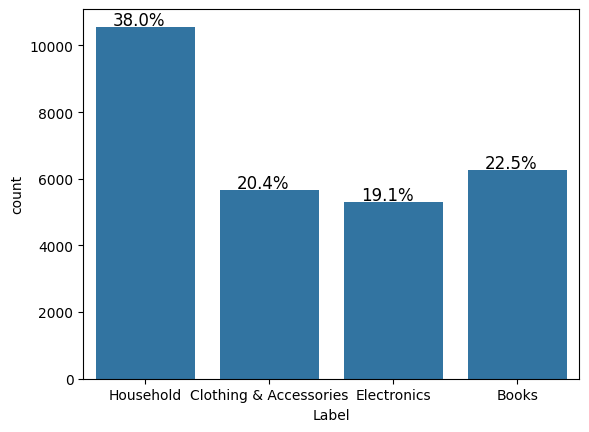

In [24]:
print('Percentage of text for each Label:')
bar_plot(df,'Label')

Wordcloud for Household Category

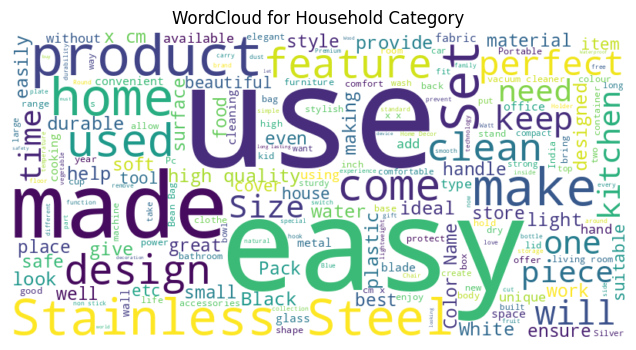

In [25]:
text = " ".join(df[df['Label']=='Household']['Text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(8,4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f"WordCloud for Household Category")
plt.show()

Wordcloud for Clothing & Accessories Category

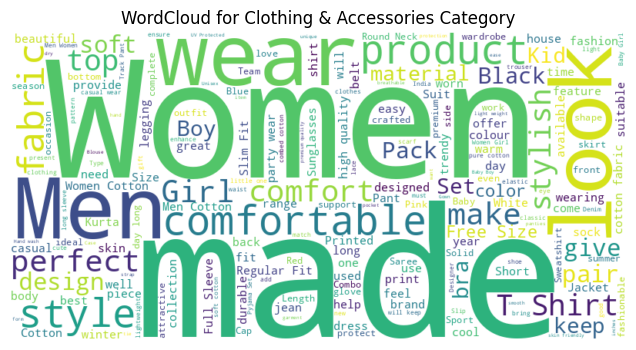

In [26]:
text = " ".join(df[df['Label']=='Clothing & Accessories']['Text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(8,4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f"WordCloud for Clothing & Accessories Category")
plt.show()

Wordcloud for Electronics Category

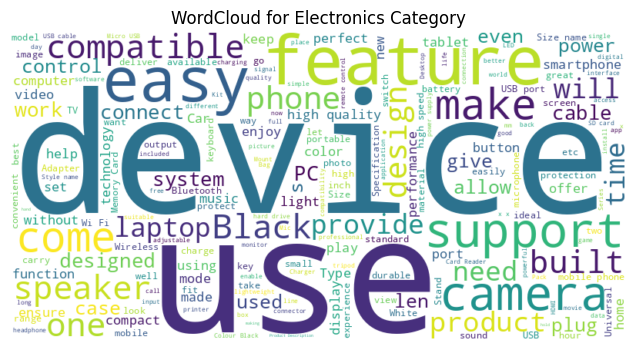

In [27]:
text = " ".join(df[df['Label']=='Electronics']['Text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(8,4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f"WordCloud for Electronics Category")
plt.show()

Wordcloud for Books Category

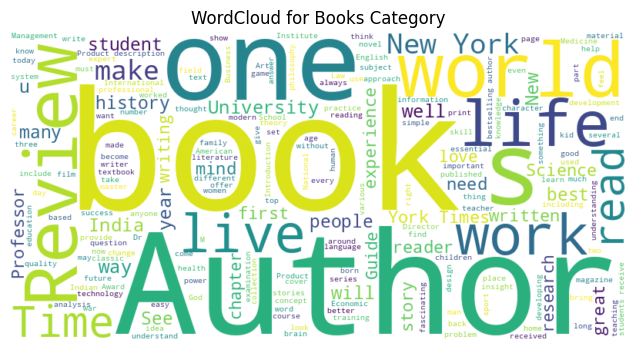

In [28]:
text = " ".join(df[df['Label']=='Books']['Text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(8,4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f"WordCloud for Books Category")
plt.show()

- There are 4 category data
- Highest number of products in the data is from Household items aorund 38% followed by books around 22% and so on.
- Most used words to describe Household products are easy, use, home, product and so on
- Most used words to describe Clothing and Accessories products are Women, men, wear, comfort and so on
- Most used words to describe Electronics products are device, feature, use, easy and so on
- Most used words to describe Books items are Author, book, one world and so on.

## Data Preparation for Modeling

-	Html tag removal.
-	Remove the numbers.
-	Tokenization.
-	Removal of Special Characters and Punctuations.
-	Conversion to lowercase.
-	Lemmatize or stemming.

In [29]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Convert to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters & punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Cleaning the whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    # Join words back
    return " ".join(words)

In [30]:
df['Cleaned_Text'] = df['Text'].apply(preprocess_text)

df.head()

,Label,Text,Cleaned_Text
0,Household,Styleys Wrought Iron Coat Rack Hanger Creative...,styleys wrought iron coat rack hanger creative...
1,Household,Cuisinart CCO-50BKN Deluxe Electric Can Opener...,cuisinart ccobkn deluxe electric opener black ...
2,Household,Anchor Penta 6 Amp 1 -Way Switch (White) - Pac...,anchor penta amp way switch white pack anchor ...
3,Clothing & Accessories,"Proline Men's Track Jacket Proline Woven, 100%...",proline men track jacket proline woven polyest...
4,Household,Chef's Garage 2 Slot Edge Grip Kitchen Knife S...,chef garage slot edge grip kitchen knife sharp...


In [31]:
df.tail()

,Label,Text,Cleaned_Text
27796,Household,Redfam Super Duper Combo of Juicer Powefree Ha...,redfam super duper combo juicer powefree hand ...
27797,Clothing & Accessories,GRAPPLE DEALS Combo Of Winter Wear Cut Woolen ...,grapple deal combo winter wear cut woolen wome...
27798,Electronics,Godox Ving V 860 II TTL Li-Ion Flash Kit for C...,godox ving v ii ttl liion flash kit canon came...
27799,Household,Konvio Elixir 15 Liter RO+UV+UF+TDS Adjuster I...,konvio elixir liter rouvuftds adjuster innovat...
27800,Clothing & Accessories,aarbee Women's Blended Cardigan aarbee women's...,aarbee womens blended cardigan aarbee womens s...


In [55]:
# Function to print the classification report and get confusion matrix in a proper format
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize = (8, 5))

    sns.heatmap(cm, annot = True,  fmt = '.2f', xticklabels = ['Household','Books','Clothing & Accessories','Electronics'], yticklabels = ['Household','Books','Clothing & Accessories','Electronics'])

    plt.ylabel('Actual')

    plt.xlabel('Predicted')
    plt.title("Confusion Matrix - Random Forest")
    plt.show()

## Model Building

Defining independt variable and dependent variable

In [33]:
# Independent variable (X)
X = df['Cleaned_Text']

# Dependent variable (y)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify = y
)

### Using countvectorizer

- Intialize countvectorizer and use it for vectorization
- Store Independent and Dependent variables
- Split the data into train and test
- Build a Random Forest model on train data
- Use Cross validation to validate the score and to find optimal n_estimators
- Plot the misclassification error for each of estimators
- Test the model on testing data
- Plot the Confusion matrix
plot word cloud for top 40 important features obtained from Count vectorizer and random forest model


In [34]:
#Initializing count vectorizer
count_vectorizer = CountVectorizer(max_features=5000)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print("Shape of X-Train-CV:", X_train_count.shape)
print("Shape of X-Test-CV:", X_test_count.shape)

Shape of X-Train-CV: (22240, 5000)
Shape of X-Test-CV: (5561, 5000)


In [35]:
# Printing the identified Unique words along with their indices
print("Vocabulary: ", count_vectorizer.vocabulary_)
# Summarizing the Encoded Texts
print("Encoded Document is:")
print(X_train_count)

Vocabulary:  {'urban': np.int64(4706), 'ladder': np.int64(2466), 'desk': np.int64(1194), 'natural': np.int64(2943), 'oak': np.int64(3022), 'essential': np.int64(1519), 'work': np.int64(4928), 'table': np.int64(4371), 'want': np.int64(4816), 'dedicated': np.int64(1148), 'working': np.int64(4932), 'space': np.int64(4124), 'home': np.int64(2128), 'provides': np.int64(3476), 'extensive': np.int64(1601), 'drawer': np.int64(1316), 'storage': np.int64(4245), 'even': np.int64(1532), 'small': np.int64(4061), 'shelf': np.int64(3949), 'glass': np.int64(1917), 'top': np.int64(4541), 'material': np.int64(2732), 'mdf': np.int64(2751), 'pvc': np.int64(3507), 'metal': np.int64(2787), 'powder': np.int64(3347), 'coating': np.int64(815), 'tempered': np.int64(4430), 'indoor': np.int64(2255), 'use': np.int64(4712), 'ul': np.int64(4660), 'team': np.int64(4411), 'assemble': np.int64(251), 'delivery': np.int64(1170), 'nylon': np.int64(3021), 'braided': np.int64(507), 'usb': np.int64(4710), 'charging': np.int6

In [36]:
print("Shape of Training set : ", X_train_count.shape)

print("Shape of test set : ", X_test_count.shape)

print("Percentage of classes in training set:")

print(y_train.value_counts(normalize = True))

print("Percentage of classes in test set:")

print(y_test.value_counts(normalize = True))

Shape of Training set :  (22240, 5000)
Shape of test set :  (5561, 5000)
Percentage of classes in training set:
Label
Household                 0.379946
Books                     0.225045
Clothing & Accessories    0.204092
Electronics               0.190917
Name: proportion, dtype: float64
Percentage of classes in test set:
Label
Household                 0.379968
Books                     0.224960
Clothing & Accessories    0.204100
Electronics               0.190973
Name: proportion, dtype: float64


In [37]:
# intializing the Random Forest model
rf_count = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
#fitting the model on train data
rf_count.fit(X_train_count, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [58]:
estimators = [100, 150, 200]
cv_scores = []

for n in estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    scores = cross_val_score(rf_count, X_train_count, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Print results
for i in range(len(estimators)):
    print(f"n_estimators={estimators[i]} → CV Accuracy={cv_scores[i]:.4f}")


n_estimators=100 → CV Accuracy=0.9250
n_estimators=150 → CV Accuracy=0.9250
n_estimators=200 → CV Accuracy=0.9250


Since here i am using random forestand here model shows good convergence and model stability

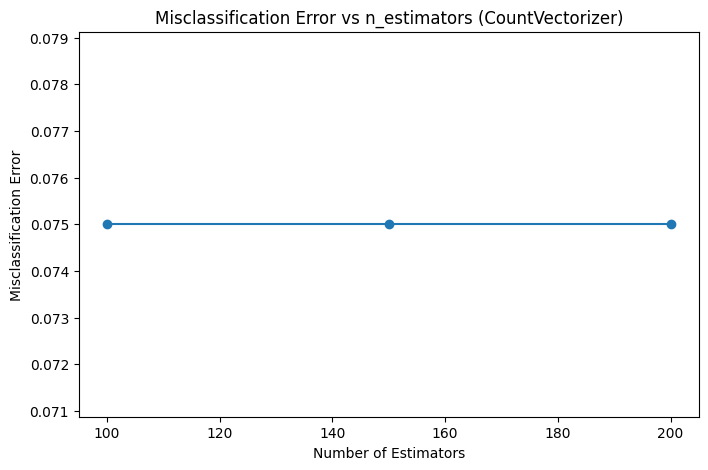

In [59]:
misclassification_error = [1 - score for score in cv_scores]

plt.figure(figsize=(8,5))
plt.plot(estimators, misclassification_error, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Misclassification Error")
plt.title("Misclassification Error vs n_estimators (CountVectorizer)")
plt.show()

Optimal n_estimators: 100
Classification Report - Random Forest (CountVectorizer)
                        precision    recall  f1-score   support

                 Books       0.93      0.93      0.93      1251
Clothing & Accessories       0.95      0.97      0.96      1135
           Electronics       0.94      0.87      0.91      1062
             Household       0.92      0.94      0.93      2113

              accuracy                           0.93      5561
             macro avg       0.94      0.93      0.93      5561
          weighted avg       0.93      0.93      0.93      5561



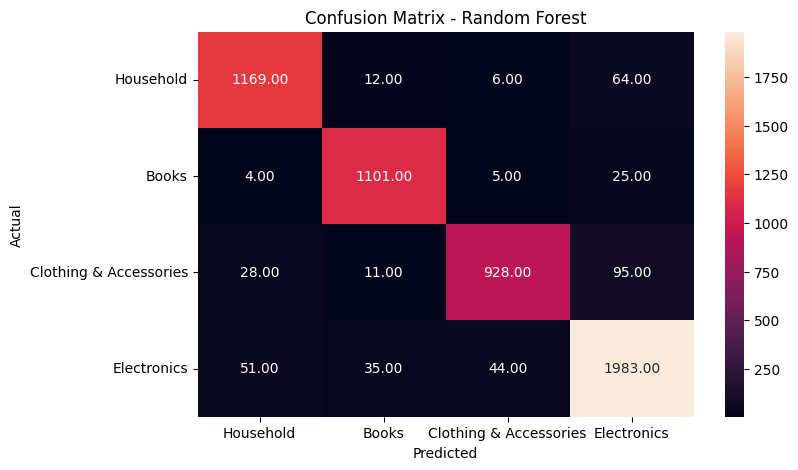

In [60]:
optimal_n = estimators[np.argmax(cv_scores)]
print("Optimal n_estimators:", optimal_n)

final_rf_cv = RandomForestClassifier(
    n_estimators=optimal_n,
    random_state=42,
    n_jobs=-1
)

#fitting the model on train data
final_rf_cv.fit(X_train_count, y_train)

y_pred_count = final_rf_cv.predict(X_test_count)

print("Classification Report - Random Forest (CountVectorizer)")
metrics_score(y_test, y_pred_count)

In [61]:
# Get feature importances
importances = rf_count.feature_importances_

# Get feature names from TCount
feature_names_count = count_vectorizer.get_feature_names_out()

# Get indices of top 20 important features
indices = np.argsort(importances)[-40:]

top_features_cv = [feature_names_count[i] for i in indices]

print("Top 40 Important Features:")
print(top_features_cv)

Top 40 Important Features:
['port', 'video', 'watt', 'made', 'room', 'speaker', 'white', 'audio', 'mm', 'easy', 'use', 'casual', 'compatible', 'phone', 'set', 'plastic', 'black', 'laptop', 'university', 'gb', 'stainless', 'cable', 'fit', 'woman', 'device', 'fabric', 'kitchen', 'boy', 'review', 'usb', 'camera', 'steel', 'girl', 'home', 'wear', 'cotton', 'men', 'book', 'womens', 'author']


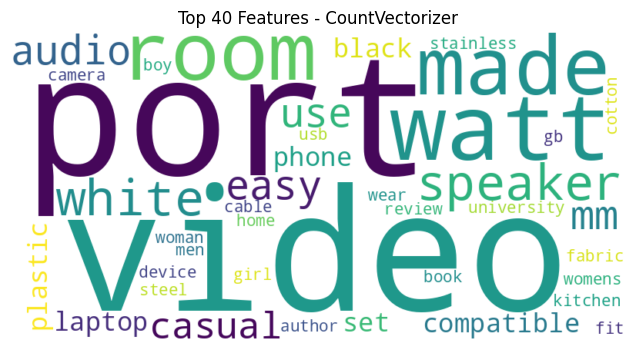

In [62]:
text = " ".join(top_features_cv)

wordcloud = WordCloud(width=800, height=400,
                      background_color='white').generate(text)

plt.figure(figsize=(8,4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 40 Features - CountVectorizer")
plt.show()

- The data used to train the model was almost equal and unbiased which helped the model to gain overall accuracy of 93%
- For Books category, model achieved 93% precision and 94% recall, showing model is very effective at correctly identifying book-related products with minimal miscalssifications.
- Electronics category showed relatively poor recall 87% compared to other categories suggesting higher mis-classification for the products under this category.
- For rest of the categories show good amount of acuracy, precision.
- Top few words were port, video, made, watt, speaker etc.

### Using TF-IDF (Term Frequency- Inverse Document Frequency)

- Intialize TFIDF and use it for vectorization
- Store Independent and Dependent variables
- Split the data into train and test
- Build a Random Forest model on train data
- Use Cross validation to validate the score and to find optimal n_estimators
- Plot the misclassification error for each of estimators
- Test the model on testing data
- Plot the Confusion matrix
plot word cloud for top 40 important features obtained from TFIDF and random forest model


In [44]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Shape of X-Train-TFIDF:", X_train_tfidf.shape)
print("Shape of X-Test-TFIDF:", X_test_tfidf.shape)

Shape of X-Train-TFIDF: (22240, 5000)
Shape of X-Test-TFIDF: (5561, 5000)


In [45]:
# get indexing
print('\nWord indexes/vocabulary:')
print(tfidf_vectorizer.vocabulary_)

# tf-idf values
print('\ntf-idf values:')
print(X_train_tfidf)


Word indexes/vocabulary:
{'urban': np.int64(4706), 'ladder': np.int64(2466), 'desk': np.int64(1194), 'natural': np.int64(2943), 'oak': np.int64(3022), 'essential': np.int64(1519), 'work': np.int64(4928), 'table': np.int64(4371), 'want': np.int64(4816), 'dedicated': np.int64(1148), 'working': np.int64(4932), 'space': np.int64(4124), 'home': np.int64(2128), 'provides': np.int64(3476), 'extensive': np.int64(1601), 'drawer': np.int64(1316), 'storage': np.int64(4245), 'even': np.int64(1532), 'small': np.int64(4061), 'shelf': np.int64(3949), 'glass': np.int64(1917), 'top': np.int64(4541), 'material': np.int64(2732), 'mdf': np.int64(2751), 'pvc': np.int64(3507), 'metal': np.int64(2787), 'powder': np.int64(3347), 'coating': np.int64(815), 'tempered': np.int64(4430), 'indoor': np.int64(2255), 'use': np.int64(4712), 'ul': np.int64(4660), 'team': np.int64(4411), 'assemble': np.int64(251), 'delivery': np.int64(1170), 'nylon': np.int64(3021), 'braided': np.int64(507), 'usb': np.int64(4710), 'charg

In [46]:
# intializing the Random Forest model
rf_tfidf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
# fitting the model on training set
rf_tfidf.fit(X_train_tfidf, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [63]:
print("Cross Validation Accuracy (TF-IDF):")

#Cross validation to find optimal n_estimators
estimators = [100, 150,200]
cv_scores_tf = []

for n in estimators:
    model = RandomForestClassifier(n_estimators=n,
                                   random_state=42,
                                   n_jobs=-1)

    scores = cross_val_score(model, X_train_tfidf, y_train,
                             cv=5, scoring='accuracy')

    cv_scores_tf.append(scores.mean())

for i in range(len(estimators)):
    print(f"n_estimators={estimators[i]} → CV Accuracy={cv_scores_tf[i]:.4f}")


Cross Validation Accuracy (TF-IDF):
n_estimators=100 → CV Accuracy=0.9250
n_estimators=150 → CV Accuracy=0.9251
n_estimators=200 → CV Accuracy=0.9256


Model with TF-IDF Random forest model, shows highest accuracy when n_estimator is 200

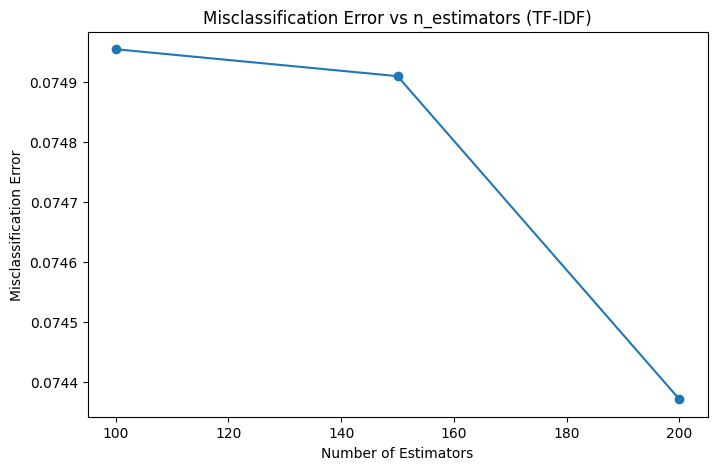

In [64]:
#Plotting mis-classification error
misclassification_error = [1 - score for score in cv_scores_tf]

plt.figure(figsize=(8,5))
plt.plot(estimators, misclassification_error, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Misclassification Error")
plt.title("Misclassification Error vs n_estimators (TF-IDF)")
plt.show()

In [65]:
optimal_n_tf = estimators[np.argmax(cv_scores_tf)]
print("Optimal n_estimators:", optimal_n_tf)

final_rf_tf = RandomForestClassifier(
    n_estimators=optimal_n_tf,
    random_state=42,
    n_jobs=-1
)

final_rf_tf.fit(X_train_tfidf, y_train)

Optimal n_estimators: 200


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

Classification Report - Random Forest (TF-IDF)
                        precision    recall  f1-score   support

                 Books       0.94      0.93      0.93      1251
Clothing & Accessories       0.95      0.96      0.96      1135
           Electronics       0.95      0.86      0.90      1062
             Household       0.91      0.94      0.92      2113

              accuracy                           0.93      5561
             macro avg       0.94      0.93      0.93      5561
          weighted avg       0.93      0.93      0.93      5561



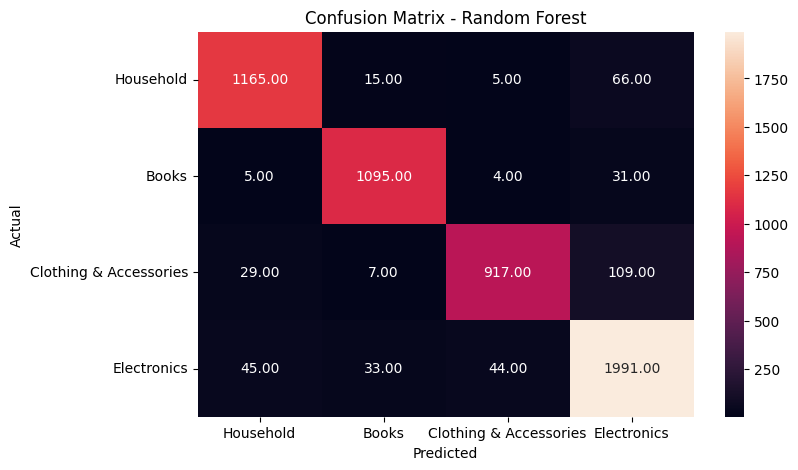

In [66]:
y_pred_tfidf = final_rf_tf.predict(X_test_tfidf)

print("Classification Report - Random Forest (TF-IDF)")
metrics_score(y_test, y_pred_tfidf)

In [67]:
# Get feature importances
importances = final_rf_tf.feature_importances_

# Get feature names from TCount
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()

# Get indices of top 20 important features
indices = np.argsort(importances)[-40:]

top_features_tfidf = [feature_names_tfidf[i] for i in indices]

print("Top 40 Important Features:")
print(top_features_tfidf)

Top 40 Important Features:
['speaker', 'audio', 'table', 'mm', 'room', 'lens', 'casual', 'white', 'color', 'use', 'made', 'easy', 'compatible', 'phone', 'set', 'plastic', 'university', 'laptop', 'black', 'gb', 'stainless', 'cable', 'woman', 'kitchen', 'fabric', 'device', 'fit', 'camera', 'boy', 'usb', 'review', 'girl', 'steel', 'home', 'wear', 'cotton', 'men', 'book', 'womens', 'author']


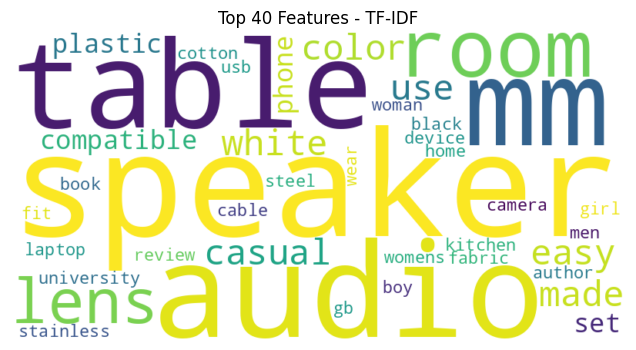

In [68]:
text = " ".join(top_features_tfidf)

wordcloud = WordCloud(width=800, height=400,
                      background_color='white').generate(text)

plt.figure(figsize=(8,4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 40 Features - TF-IDF")
plt.show()

- The Random Forest model using TF-IDF vectorization achieved an overall accuracy of 93%, indicating strong performance in classifying e-commerce product descriptions into their correct categories.
- The Clothing & Accessories category performed the best, with a precision of 95%, recall of 96%, and F1-score of 0.96, suggesting that this category contains distinct keywords that are easily identifiable by the model.
- The Books category also showed strong performance, achieving an F1-score of 0.93, demonstrating the model's ability to correctly identify book-related product descriptions.

## Summary

---



- Here, both CountVectorizer and TF-IDF vectorization methods achieved the same overall accuracy of 93%, indicating that both approaches are effective for product category classification.
- Clothing & Accessories category performed the best in both models achieving highest precision around 96%.
- Electronics category had the lowest recall in both models, but TF-IDF showed slightly lower recall (86%) compared to CountVectorizer (87%), suggesting that some electronics products are still occasionally misclassified.
- TF-IDF slightly improves the importance of meaningful words by reducing the weight of very frequent terms, while CountVectorizer simply counts word occurrences. However, in this dataset both methods produced very similar predictive performance.
- Overall, both vectorization techniques work well for this classification problem, but TF-IDF is generally preferred in NLP tasks because it better captures the importance of words across documents and the above model can be used to automate product categorization based on product description by the business unit.

## Happy Learning!

In [69]:
#!jupyter nbconvert --to html --output NLP_Learner_Notebook.html "NLP_Learner_Notebook.ipynb"
!jupyter nbconvert --to html "/content/drive/MyDrive/16th Week Intro to Neural NW/18th NLP/Project1/Question_Notebook_NLP_E_Commerce.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/16th Week Intro to Neural NW/18th NLP/Project1/Question_Notebook_NLP_E_Commerce.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 2478993 bytes to /content/drive/MyDrive/16th Week Intro to Neural NW/18th NLP/Project1/Question_Notebook_NLP_E_Commerce.html
